In [1]:
from sklearn.datasets import fetch_california_housing as house
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [2]:
hs = house(return_X_y=False) 

In [3]:
dt = np.array(hs['data'])

In [4]:
print(dt.shape)

(20640, 8)


In [5]:
tg = np.array(hs['target'])

In [6]:
print(tg)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [7]:
#setting the random seed
np.random.seed(9432)

In [8]:
#random shuffling
n_samples = len(dt)
shuffled_indices = np.random.permutation(n_samples)

In [9]:
#splitting
test_split_idx = int(n_samples * 0.8)       # 80% mark
val_split_idx = int(test_split_idx * 0.75)   # 75% of 80% is 60% mark
train_idx = shuffled_indices[:val_split_idx]
val_idx = shuffled_indices[val_split_idx:test_split_idx]
test_idx = shuffled_indices[test_split_idx:]

In [10]:
#final splitting
X_train, y_train = dt[train_idx], tg[train_idx]
X_val, y_val     = dt[val_idx], tg[val_idx]
X_test, y_test   = dt[test_idx], tg[test_idx]
print(X_train)

[[   3.0089       24.            5.93950178 ...    2.09608541
    38.89       -120.01      ]
 [   1.3801       25.            4.7375     ...    2.51666667
    33.78       -116.46      ]
 [   5.021        23.            5.44859813 ...    2.4517134
    33.75       -117.81      ]
 ...
 [   7.7785       13.            7.96969697 ...    3.60606061
    34.25       -118.78      ]
 [   3.7167       46.            4.69982238 ...    2.51865009
    37.78       -122.5       ]
 [   5.8777       27.            5.61851016 ...    2.44243792
    33.63       -117.95      ]]


In [11]:
#Scaling the feature dimension
scaler = StandardScaler()
X_train_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.transform(X_test)
X_val_Scaled = scaler.transform(X_val)

#Feature Augmentation (Bias Inclusion)
n_samples_train = X_train_Scaled.shape[0]
ones_train = np.ones((n_samples_train, 1))
X_train_aug = np.hstack((ones_train, X_train_Scaled))

# Validation Set
n_samples_val = X_val_Scaled.shape[0]
ones_val = np.ones((n_samples_val, 1))
X_val_aug = np.hstack((ones_val, X_val_Scaled))

# Test Set (Fixed)
n_samples_test = X_test_Scaled.shape[0]
ones_test = np.ones((n_samples_test, 1))
X_test_aug = np.hstack((ones_test, X_test_Scaled))

print(X_train_aug.shape)

(12384, 9)


In [12]:
#Scaling the Y
y_train_2d = y_train.reshape(-1, 1)
y_val_2d   = y_val.reshape(-1, 1)
y_test_2d  = y_test.reshape(-1, 1)

y_train_Scaled = scaler.fit_transform(y_train_2d)
y_test_Scaled = scaler.transform(y_test_2d)
y_val_Scaled = scaler.transform(y_val_2d)

In [13]:
#Task2
def train_minibatch_gd(X_tr, y_tr, X_v, y_v, lr, batch_size, max_epochs=1000, patience=100):
    n_samples, n_features = X_tr.shape
    weights = np.zeros(n_features)  
    
    best_weights = None
    best_val_mse = float('inf')
    best_epoch = 0
    patience_counter = 0
    
    train_mse_history = []
    val_mse_history = []
    
    for epoch in range(max_epochs):
        indices = np.random.permutation(n_samples)
        X_tr_shuffled = X_tr[indices]
        y_tr_shuffled = y_tr[indices]
        
        epoch_train_loss = 0.0
        
        for i in range(0, n_samples, batch_size):
            X_batch = X_tr_shuffled[i:i+batch_size]
            y_batch = y_tr_shuffled[i:i+batch_size]
            b_size = X_batch.shape[0]
            
            predictions = np.dot(X_batch, weights)
            errors = predictions - y_batch
            
            batch_loss = np.mean(errors ** 2)
            epoch_train_loss += batch_loss * b_size
            
            gradient = (2 / b_size) * np.dot(X_batch.T, errors)
            
            weights -= lr * gradient
            
        epoch_train_mse = epoch_train_loss / n_samples
        train_mse_history.append(epoch_train_mse)
        
        val_preds = np.dot(X_v, weights)
        val_mse = np.mean((val_preds - y_v) ** 2)
        val_mse_history.append(val_mse)
        
        if val_mse < best_val_mse:
            best_val_mse = val_mse
            best_weights = weights.copy()
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
                
    return best_weights, best_epoch, train_mse_history, val_mse_history

In [14]:
#training the model
#1. Learning Rate(lr) = 10^-5
weight, epoch, trainHist, valHist = train_minibatch_gd(X_train_aug, y_train_Scaled.ravel(),X_val_aug, y_val_Scaled.ravel(),lr= 0.00001,batch_size= 128)

In [15]:
print(trainHist)
print(valHist)

[np.float64(0.9989665056601912), np.float64(0.9968764246825157), np.float64(0.9947953525797424), np.float64(0.9927180770643946), np.float64(0.9906548720640255), np.float64(0.988598091092095), np.float64(0.9865502444187659), np.float64(0.9845102217130048), np.float64(0.9824793188712938), np.float64(0.9804579182281908), np.float64(0.9784441478240764), np.float64(0.9764386587320227), np.float64(0.9744419593493061), np.float64(0.9724531481000042), np.float64(0.9704700179672006), np.float64(0.9684959914046214), np.float64(0.9665319229354776), np.float64(0.9645763963658575), np.float64(0.9626278722174288), np.float64(0.9606869774778796), np.float64(0.9587565276307625), np.float64(0.9568327380701663), np.float64(0.9549138473499972), np.float64(0.9530047678996324), np.float64(0.9511032271704662), np.float64(0.9492115031287499), np.float64(0.9473255021743102), np.float64(0.9454479720425925), np.float64(0.9435786039891573), np.float64(0.9417175721498944), np.float64(0.9398643772198583), np.float

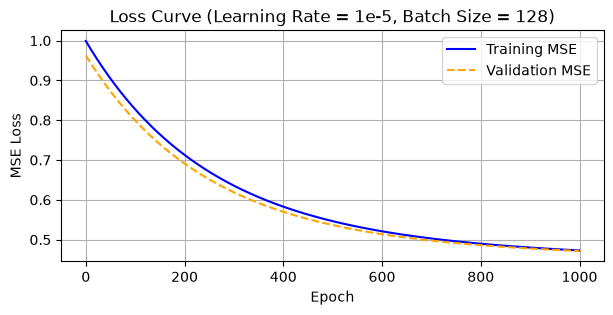

In [16]:
plt.figure(figsize=(7,3))
plt.plot(trainHist, label='Training MSE', color='blue')
plt.plot(valHist, label='Validation MSE', color='orange', linestyle='--')
plt.title('Loss Curve (Learning Rate = 1e-5, Batch Size = 128)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

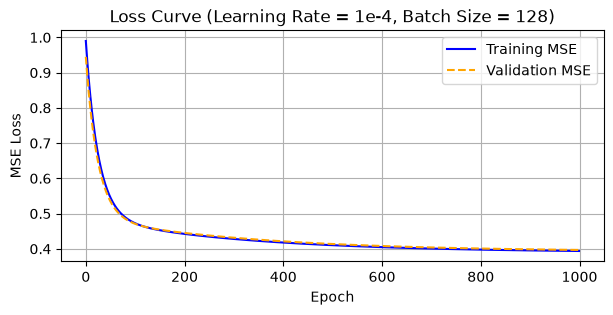

In [17]:
weight, epoch, trainHist, valHist = train_minibatch_gd(X_train_aug, y_train_Scaled.ravel(),X_val_aug, y_val_Scaled.ravel(),lr= 0.0001,batch_size= 128)
plt.figure(figsize=(7, 3))
plt.plot(trainHist, label='Training MSE', color='blue')
plt.plot(valHist, label='Validation MSE', color='orange', linestyle='--')
plt.title('Loss Curve (Learning Rate = 1e-4, Batch Size = 128)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

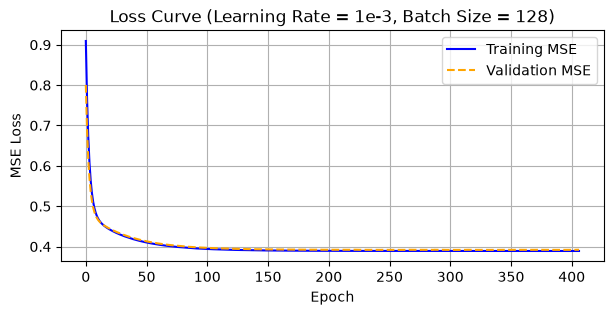

In [18]:
weight, epoch, trainHist, valHist = train_minibatch_gd(X_train_aug, y_train_Scaled.ravel(),X_val_aug, y_val_Scaled.ravel(),lr= 0.001,batch_size= 128)
plt.figure(figsize=(7, 3))
plt.plot(trainHist, label='Training MSE', color='blue')
plt.plot(valHist, label='Validation MSE', color='orange', linestyle='--')
plt.title('Loss Curve (Learning Rate = 1e-3, Batch Size = 128)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

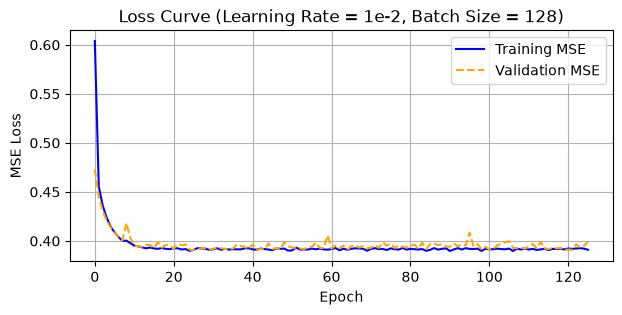

In [19]:
weight, epoch, trainHist, valHist = train_minibatch_gd(X_train_aug, y_train_Scaled.ravel(),X_val_aug, y_val_Scaled.ravel(),lr= 0.01,batch_size= 128)
plt.figure(figsize=(7, 3))
plt.plot(trainHist, label='Training MSE', color='blue')
plt.plot(valHist, label='Validation MSE', color='orange', linestyle='--')
plt.title('Loss Curve (Learning Rate = 1e-2, Batch Size = 128)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_14116\292788774.py:40: RuntimeWarning: overflow encountered in square
  val_mse = np.mean((val_preds - y_v) ** 2)
C:\Users\Hp\AppData\Local\Temp\ipykernel_14116\292788774.py:29: RuntimeWarning: overflow encountered in square
  batch_loss = np.mean(errors ** 2)
C:\Users\Hp\AppData\Roaming\Python\Python314\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


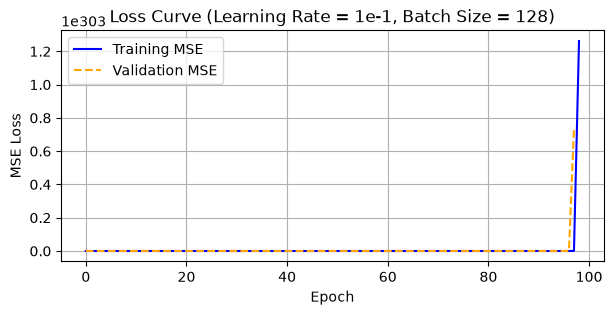

In [20]:
weight, epoch, trainHist, valHist = train_minibatch_gd(X_train_aug, y_train_Scaled.ravel(),X_val_aug, y_val_Scaled.ravel(),lr= 0.1,batch_size= 128)
plt.figure(figsize=(7, 3))
plt.plot(trainHist, label='Training MSE', color='blue')
plt.plot(valHist, label='Validation MSE', color='orange', linestyle='--')
plt.title('Loss Curve (Learning Rate = 1e-1, Batch Size = 128)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_14116\292788774.py:30: RuntimeWarning: overflow encountered in scalar add
  epoch_train_loss += batch_loss * b_size
C:\Users\Hp\AppData\Local\Temp\ipykernel_14116\292788774.py:29: RuntimeWarning: overflow encountered in square
  batch_loss = np.mean(errors ** 2)
C:\Users\Hp\AppData\Local\Temp\ipykernel_14116\292788774.py:40: RuntimeWarning: overflow encountered in square
  val_mse = np.mean((val_preds - y_v) ** 2)
C:\Users\Hp\AppData\Local\Temp\ipykernel_14116\292788774.py:32: RuntimeWarning: overflow encountered in dot
  gradient = (2 / b_size) * np.dot(X_batch.T, errors)
C:\Users\Hp\AppData\Local\Temp\ipykernel_14116\292788774.py:26: RuntimeWarning: invalid value encountered in dot
  predictions = np.dot(X_batch, weights)
C:\Users\Hp\AppData\Local\Temp\ipykernel_14116\292788774.py:32: RuntimeWarning: invalid value encountered in dot
  gradient = (2 / b_size) * np.dot(X_batch.T, errors)


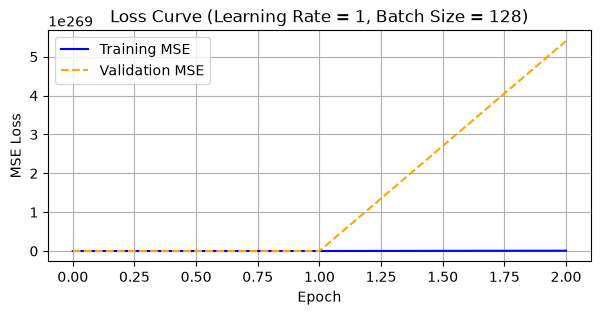

In [21]:
weight, epoch, trainHist, valHist = train_minibatch_gd(X_train_aug, y_train_Scaled.ravel(),X_val_aug, y_val_Scaled.ravel(),lr= 1,batch_size= 128)
plt.figure(figsize=(7, 3))
plt.plot(trainHist, label='Training MSE', color='blue')
plt.plot(valHist, label='Validation MSE', color='orange', linestyle='--')
plt.title('Loss Curve (Learning Rate = 1, Batch Size = 128)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\Hp\AppData\Local\Temp\ipykernel_14116\292788774.py:29: RuntimeWarning: overflow encountered in square
  batch_loss = np.mean(errors ** 2)
C:\Users\Hp\AppData\Local\Temp\ipykernel_14116\292788774.py:40: RuntimeWarning: overflow encountered in square
  val_mse = np.mean((val_preds - y_v) ** 2)
C:\Users\Hp\AppData\Local\Temp\ipykernel_14116\292788774.py:32: RuntimeWarning: overflow encountered in dot
  gradient = (2 / b_size) * np.dot(X_batch.T, errors)
C:\Users\Hp\AppData\Local\Temp\ipykernel_14116\292788774.py:26: RuntimeWarning: invalid value encountered in dot
  predictions = np.dot(X_batch, weights)


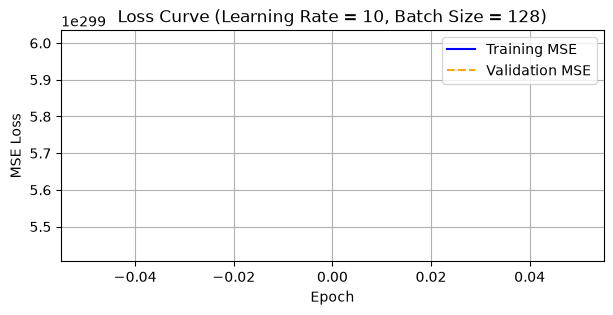

In [22]:
weight, epoch, trainHist, valHist = train_minibatch_gd(X_train_aug, y_train_Scaled.ravel(),X_val_aug, y_val_Scaled.ravel(),lr= 10,batch_size= 128)
plt.figure(figsize=(7, 3))
plt.plot(trainHist, label='Training MSE', color='blue')
plt.plot(valHist, label='Validation MSE', color='orange', linestyle='--')
plt.title('Loss Curve (Learning Rate = 10, Batch Size = 128)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

**From the plots, it can be inferred that here the best learning rate is 0.01**

C:\Users\Hp\AppData\Local\Temp\ipykernel_14116\292788774.py:30: RuntimeWarning: overflow encountered in scalar add
  epoch_train_loss += batch_loss * b_size
C:\Users\Hp\AppData\Local\Temp\ipykernel_14116\292788774.py:29: RuntimeWarning: overflow encountered in square
  batch_loss = np.mean(errors ** 2)
C:\Users\Hp\AppData\Local\Temp\ipykernel_14116\292788774.py:40: RuntimeWarning: overflow encountered in square
  val_mse = np.mean((val_preds - y_v) ** 2)


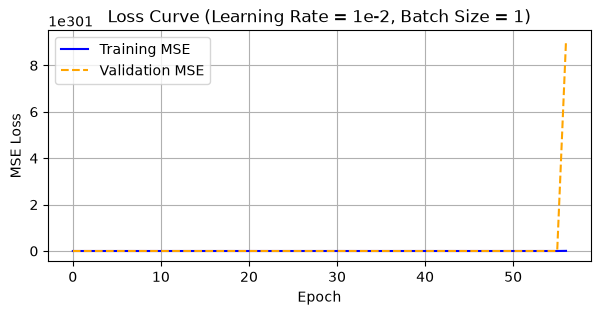

In [23]:
weight, epoch, trainHist, valHist = train_minibatch_gd(X_train_aug, y_train_Scaled.ravel(),X_val_aug, y_val_Scaled.ravel(),lr= 0.01,batch_size= 1)
plt.figure(figsize=(7, 3))
plt.plot(trainHist, label='Training MSE', color='blue')
plt.plot(valHist, label='Validation MSE', color='orange', linestyle='--')
plt.title('Loss Curve (Learning Rate = 1e-2, Batch Size = 1)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

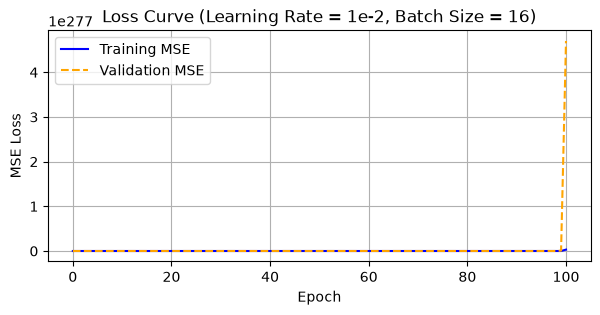

In [24]:
weight, epoch, trainHist, valHist = train_minibatch_gd(X_train_aug, y_train_Scaled.ravel(),X_val_aug, y_val_Scaled.ravel(),lr= 0.01,batch_size= 16)
plt.figure(figsize=(7, 3))
plt.plot(trainHist, label='Training MSE', color='blue')
plt.plot(valHist, label='Validation MSE', color='orange', linestyle='--')
plt.title('Loss Curve (Learning Rate = 1e-2, Batch Size = 16)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

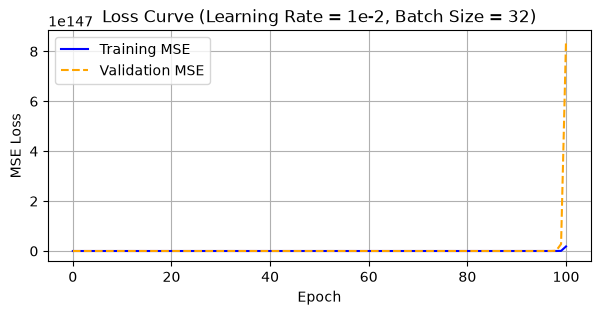

In [25]:
weight, epoch, trainHist, valHist = train_minibatch_gd(X_train_aug, y_train_Scaled.ravel(),X_val_aug, y_val_Scaled.ravel(),lr= 0.01,batch_size= 32)
plt.figure(figsize=(7, 3))
plt.plot(trainHist, label='Training MSE', color='blue')
plt.plot(valHist, label='Validation MSE', color='orange', linestyle='--')
plt.title('Loss Curve (Learning Rate = 1e-2, Batch Size = 32)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

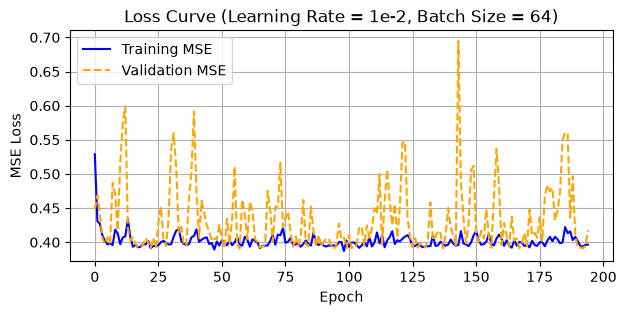

In [26]:
weight, epoch, trainHist, valHist = train_minibatch_gd(X_train_aug, y_train_Scaled.ravel(),X_val_aug, y_val_Scaled.ravel(),lr= 0.01,batch_size= 64)
plt.figure(figsize=(7, 3))
plt.plot(trainHist, label='Training MSE', color='blue')
plt.plot(valHist, label='Validation MSE', color='orange', linestyle='--')
plt.title('Loss Curve (Learning Rate = 1e-2, Batch Size = 64)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

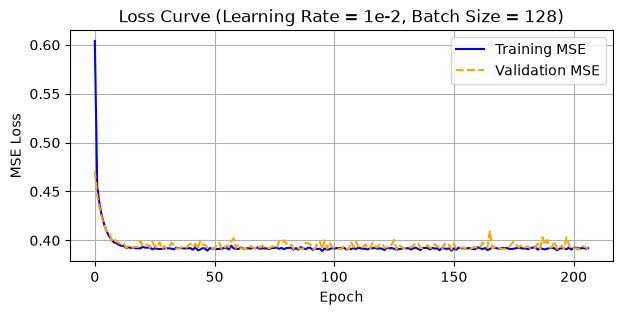

In [27]:
weight, epoch, trainHist, valHist = train_minibatch_gd(X_train_aug, y_train_Scaled.ravel(),X_val_aug, y_val_Scaled.ravel(),lr= 0.01,batch_size= 128)
plt.figure(figsize=(7, 3))
plt.plot(trainHist, label='Training MSE', color='blue')
plt.plot(valHist, label='Validation MSE', color='orange', linestyle='--')
plt.title('Loss Curve (Learning Rate = 1e-2, Batch Size = 128)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

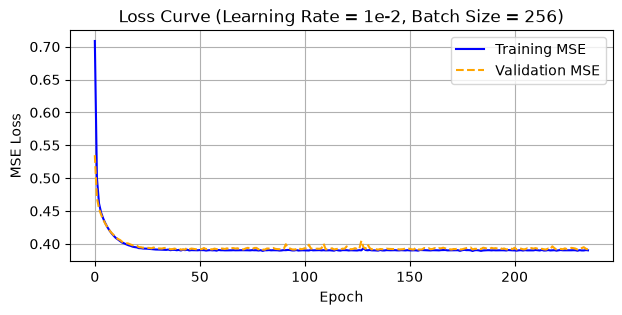

In [28]:
weight, epoch, trainHist, valHist = train_minibatch_gd(X_train_aug, y_train_Scaled.ravel(),X_val_aug, y_val_Scaled.ravel(),lr= 0.01,batch_size= 256)
plt.figure(figsize=(7, 3))
plt.plot(trainHist, label='Training MSE', color='blue')
plt.plot(valHist, label='Validation MSE', color='orange', linestyle='--')
plt.title('Loss Curve (Learning Rate = 1e-2, Batch Size = 256)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

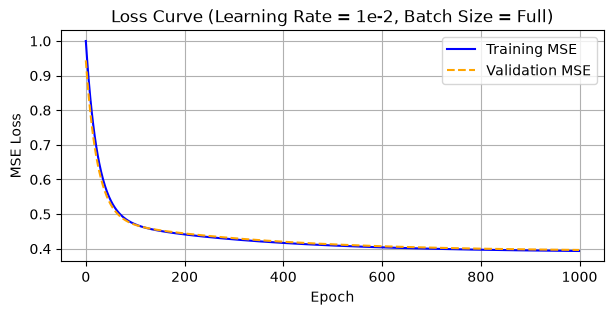

In [29]:
weight, epoch, trainHist, valHist = train_minibatch_gd(X_train_aug, y_train_Scaled.ravel(),X_val_aug, y_val_Scaled.ravel(),lr= 0.01,batch_size= X_train.shape[0])
plt.figure(figsize=(7, 3))
plt.plot(trainHist, label='Training MSE', color='blue')
plt.plot(valHist, label='Validation MSE', color='orange', linestyle='--')
plt.title('Loss Curve (Learning Rate = 1e-2, Batch Size = Full)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

**Task 5: Inference Testing**

It is clear from the above plots that *learning rate: 0.01* with *Batch size: 256*, provides the best validation performance

In [30]:
#Best Fit Model 
weight, epoch, trainHist, valHist = train_minibatch_gd(X_train_aug, y_train_Scaled.ravel(),X_val_aug, y_val_Scaled.ravel(),lr= 0.01,batch_size= 256)
y_train_pred_std = X_train_aug @ weight
y_val_pred_std   = X_val_aug @ weight
y_test_pred_std  = X_test_aug @ weight

y_mean = np.mean(y_train)
y_std = np.std(y_train)

y_train_pred = y_train_pred_std * y_std + y_mean
y_val_pred   = y_val_pred_std * y_std + y_mean
y_test_pred  = y_test_pred_std * y_std + y_mean

y_train_std = (y_train - y_mean) / y_std
y_val_std   = (y_val - y_mean) / y_std
y_test_std  = (y_test - y_mean) / y_std

y_train_true = y_train_std * y_std + y_mean
y_val_true   = y_val_std * y_std + y_mean
y_test_true  = y_test_std * y_std + y_mean


In [31]:
#Error Calculation
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - ss_res / ss_tot


**Final Results**

In [34]:
results = {
    "Train": [
        rmse(y_train_true, y_train_pred),
        mae(y_train_true, y_train_pred),
        mape(y_train_true, y_train_pred),
        r2_score(y_train_true, y_train_pred)
    ],

    "Validation": [
        rmse(y_val_true, y_val_pred),
        mae(y_val_true, y_val_pred),
        mape(y_val_true, y_val_pred),
        r2_score(y_val_true, y_val_pred)
    ],

    "Test": [
        rmse(y_test_true, y_test_pred),
        mae(y_test_true, y_test_pred),
        mape(y_test_true, y_test_pred),
        r2_score(y_test_true, y_test_pred)
    ]
}

import pandas as pd

metrics_table = pd.DataFrame(
    results,
    index=["RMSE", "MAE", "MAPE (%)", "R²"]
).T

print(metrics_table.round(5))

               RMSE      MAE  MAPE (%)       R²
Train       0.72211  0.52809  31.52514  0.61075
Validation  0.72376  0.53347  31.37658  0.59455
Test        0.73248  0.53255  31.25878  0.60132


**Final Plot**

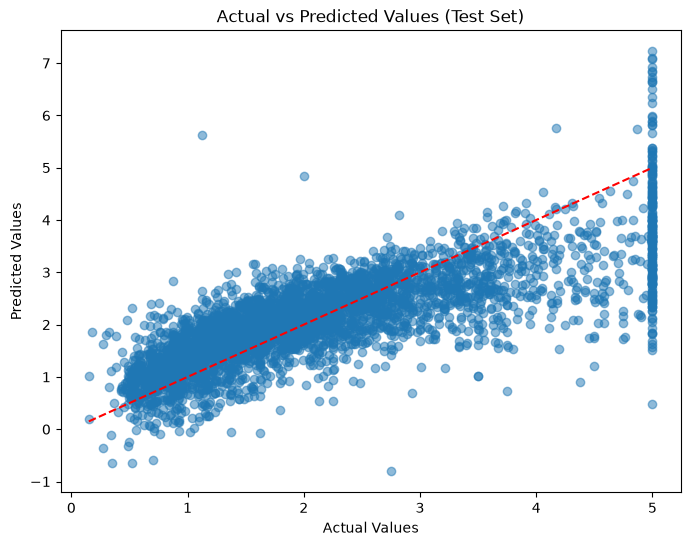

In [33]:

plt.figure(figsize=(8,6))

plt.scatter(y_test_true,
            y_test_pred,
            alpha=0.5)

plt.plot(
    [y_test_true.min(), y_test_true.max()],
    [y_test_true.min(), y_test_true.max()],
    'r--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values (Test Set)")

plt.show()